In [23]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [24]:
 # Reading in dataset
bcd_raw = pd.read_csv("NKI_cleaned.csv")

# Dropping unnecessary columns
drop1 = bcd_raw.columns[17:]
bcd = bcd_raw.drop(drop1, axis=1)

drop2 = [bcd.columns[0], bcd.columns[15]]
bcd = bcd.drop(drop2, axis=1)
#bcd.head()

In [25]:
# Renaming column titles for clarity
replace_indices = [1,2,3,4,5,6,7,8,9,10,11,12,13,14]
names = ["Age", "Death", "Indicated Survival Time", "Indicated Recurrence Time", "Chemotherapy Used", "Hormonal Therapy Used", "Amputation Used", "Histological Type", "Tumour Diameter", "No. of Nodes", "Cancer Grade", "Blood Vessel/ Lymph Cell Infiltration Level", "Lymphocytic Infiltration Level", "Expression Level of Estrogen Receptor Gene"]

replace = bcd.columns[replace_indices]
bcd.rename(columns=dict(zip(replace, names)), inplace=True)

In [26]:
# Creating column "Different Therapies"
bcd["Different Therapies"] = bcd["Chemotherapy Used"] + bcd["Hormonal Therapy Used"] + bcd["Amputation Used"]

# Creating column "Treatment Combinations"
treatment_combinations = []

for index, row in bcd.iterrows():
    therapies = ""
    if row["Chemotherapy Used"] == 1:
        therapies += "Chemotherapy & "
    if row["Hormonal Therapy Used"] == 1:
        therapies += "Hormonal Therapy & "
    if row["Amputation Used"] == 1:
        therapies += "Amputation & "
    therapies = therapies.rstrip(" & ")
    if therapies == "":
        therapies = "None"
    treatment_combinations.append(therapies)

bcd["Treatment Combinations"] = treatment_combinations

# Defining low/ high ESR1 expression level groups
median_esr1 = bcd["Expression Level of Estrogen Receptor Gene"].median()
low_esr1 = bcd[bcd["Expression Level of Estrogen Receptor Gene"] <= median_esr1]
high_esr1 = bcd[bcd["Expression Level of Estrogen Receptor Gene"] > median_esr1]

In [27]:
# Checking data types
print("Types of Data in Each Column:")
print(bcd.dtypes)

# Getting description of working dataset
print("Overview of Data:")
print(bcd.describe())

# Checking for missing values
print("Missing Values:")
print(bcd.isnull().sum())

Types of Data in Each Column:
ID                                               int64
Age                                              int64
Death                                            int64
Indicated Survival Time                        float64
Indicated Recurrence Time                      float64
Chemotherapy Used                                int64
Hormonal Therapy Used                            int64
Amputation Used                                  int64
Histological Type                                int64
Tumour Diameter                                  int64
No. of Nodes                                     int64
Cancer Grade                                     int64
Blood Vessel/ Lymph Cell Infiltration Level      int64
Lymphocytic Infiltration Level                   int64
Expression Level of Estrogen Receptor Gene     float64
Different Therapies                              int64
Treatment Combinations                          object
dtype: object
Overview of Data:
   

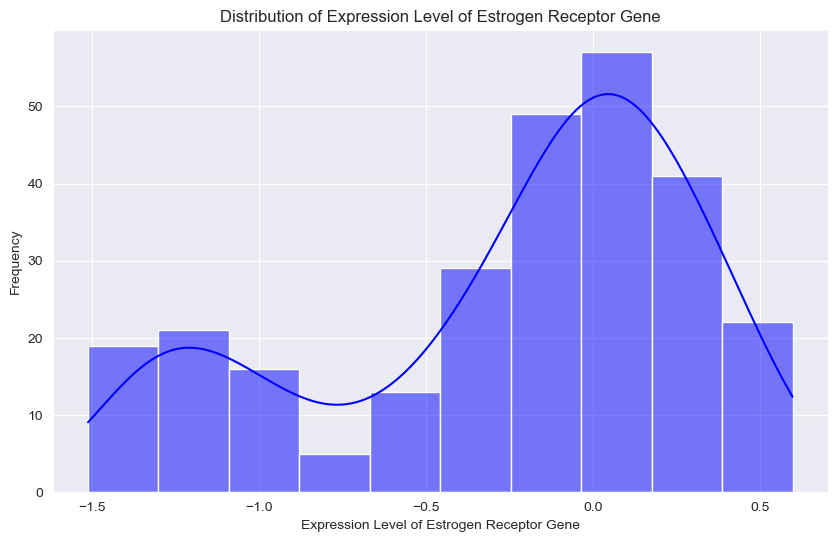

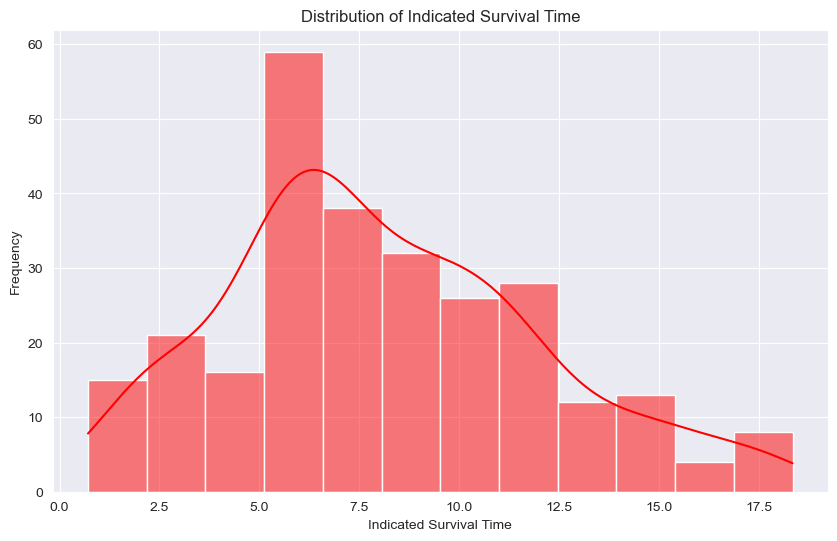

In [28]:
# Plotting data of interest to gain an initial overview of what we are working with
plt.figure(figsize=(10, 6))
sns.histplot(bcd["Expression Level of Estrogen Receptor Gene"], label="Whole Dataset", kde=True, color="blue")
plt.title("Distribution of Expression Level of Estrogen Receptor Gene")
plt.xlabel("Expression Level of Estrogen Receptor Gene")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(bcd["Indicated Survival Time"], label="Whole Dataset", kde=True, color="red")
plt.title("Distribution of Indicated Survival Time")
plt.xlabel("Indicated Survival Time")
plt.ylabel("Frequency")
plt.show()

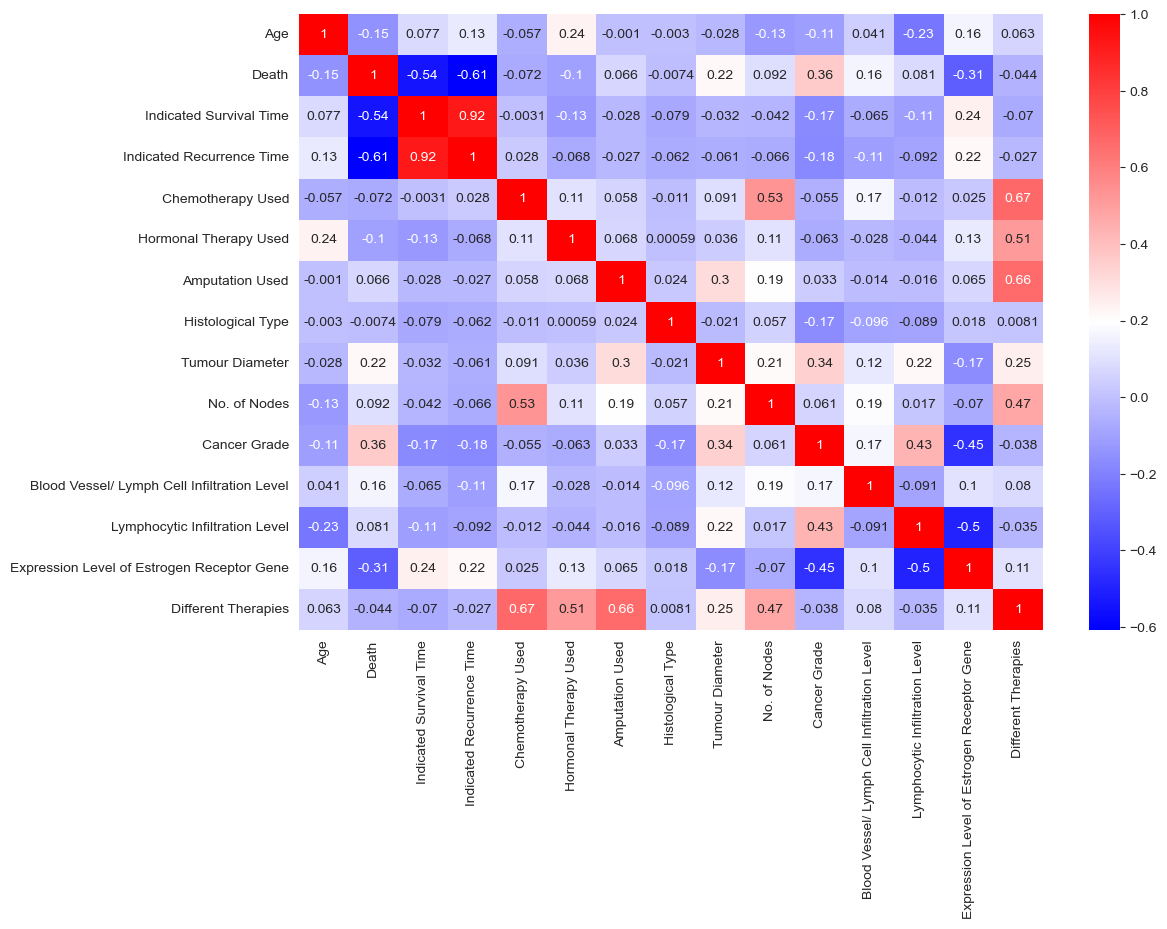

In [29]:
# Creating and displaying Pearson Correlation Matrix
plt.figure(figsize=(12,8))
sns.heatmap(bcd.drop(["ID", "Treatment Combinations"], axis=1).corr(method="pearson"), annot=True, cmap="bwr")
plt.show()

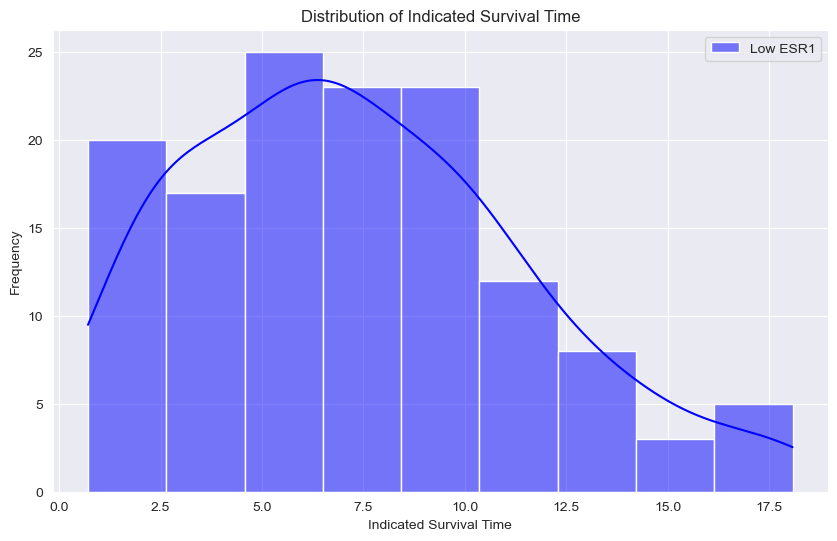

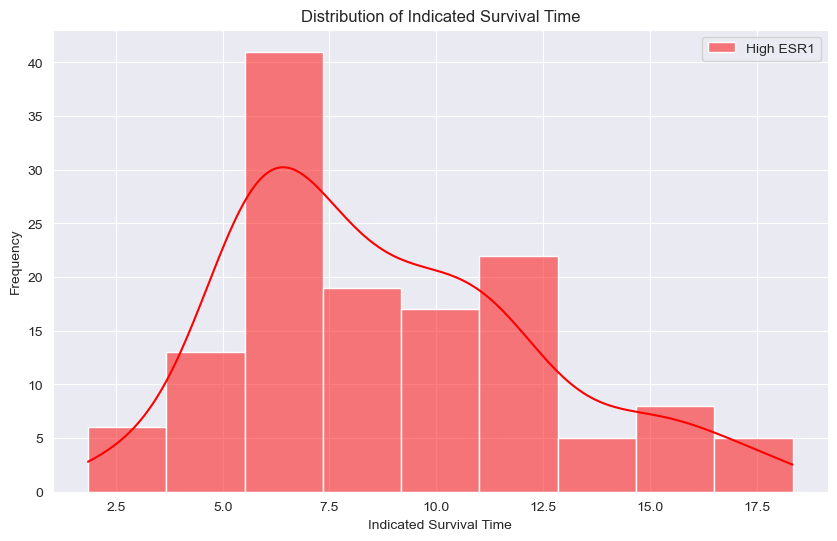

Shapiro-Wilk Test for Low ESR1 - Statistic: 0.9638566974832433 P-value: 0.0011411882053584978
Shapiro-Wilk Test for High ESR1 - Statistic: 0.9494545700547582 P-value: 7.02713392875987e-05


In [30]:
# Checking distributions of low/ high ESR1 expression groups to assist in choice of statistical test
plt.figure(figsize=(10, 6))
sns.histplot(low_esr1["Indicated Survival Time"], label="Low ESR1", kde=True, color="blue")

plt.legend()
plt.title("Distribution of Indicated Survival Time")
plt.xlabel("Indicated Survival Time")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(high_esr1["Indicated Survival Time"], label="High ESR1", kde=True, color="red")
plt.legend()
plt.title("Distribution of Indicated Survival Time")
plt.xlabel("Indicated Survival Time")
plt.ylabel("Frequency")
plt.show()

# Performing a Shapiro-Wilk test for low/ high ESR1 expression groups to assist in choice of statistical test
stat_low, p_shapiro_low = stats.shapiro(low_esr1["Indicated Survival Time"])
stat_high, p_shapiro_high = stats.shapiro(high_esr1["Indicated Survival Time"])
print("Shapiro-Wilk Test for Low ESR1 - Statistic:", stat_low, "P-value:", p_shapiro_low)
print("Shapiro-Wilk Test for High ESR1 - Statistic:", stat_high, "P-value:", p_shapiro_high)

In [31]:
# Using non-parametric statistical method to check for significant difference in indicated survival time between ESR1 groups
u_stat, p_val = stats.mannwhitneyu(low_esr1["Indicated Survival Time"], high_esr1["Indicated Survival Time"])
print("Mann-Whitney U Test - U statistic:", u_stat, "P-value:", p_val)

Mann-Whitney U Test - U statistic: 7135.0 P-value: 0.0011274507190116767


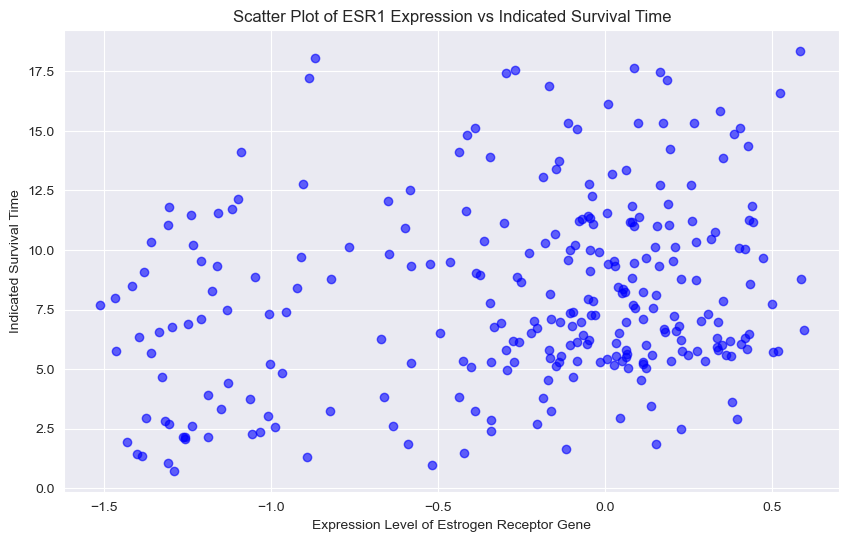

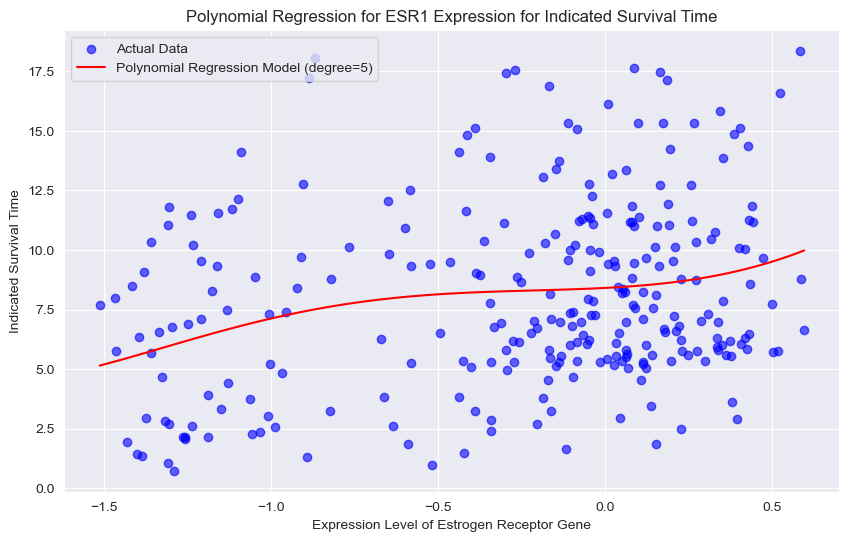

Minimum: 5.149518790857536 Maximum: 9.981810419552602


In [34]:
# Plotting initial scatterplot to assist with model choice
plt.figure(figsize=(10, 6))
plt.scatter(bcd["Expression Level of Estrogen Receptor Gene"], bcd["Indicated Survival Time"], color="blue", alpha=0.6)
plt.title("Scatter Plot of ESR1 Expression vs Indicated Survival Time")
plt.xlabel("Expression Level of Estrogen Receptor Gene")
plt.ylabel("Indicated Survival Time")
plt.show()

# Creating polynomial regression function
def plot_polynomial_regression(x, y, degree):
    coeffs = np.polyfit(x, y, degree)
    poly = np.poly1d(coeffs)

    x_poly = np.linspace(x.min(), x.max(), 100)
    y_poly = poly(x_poly)
    
    # Plotting polynomial regression
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.6, color="blue", label="Actual Data")
    plt.plot(x_poly, y_poly, color="red", label="Polynomial Regression Model (degree="+str(degree)+")")
    plt.title("Polynomial Regression for ESR1 Expression for Indicated Survival Time")
    plt.xlabel("Expression Level of Estrogen Receptor Gene")
    plt.ylabel("Indicated Survival Time")
    plt.legend()
    plt.show()
    
    # Displaying minimum and maximum values on y-axis
    print("Minimum:", min(y_poly), "Maximum:", max(y_poly))
    
# Getting values for regression
a = bcd["Expression Level of Estrogen Receptor Gene"].values
b = bcd["Indicated Survival Time"].values

# Plotting polynomial regression of degree 5
plot_polynomial_regression(a, b, degree=5)

<Figure size 1200x800 with 0 Axes>

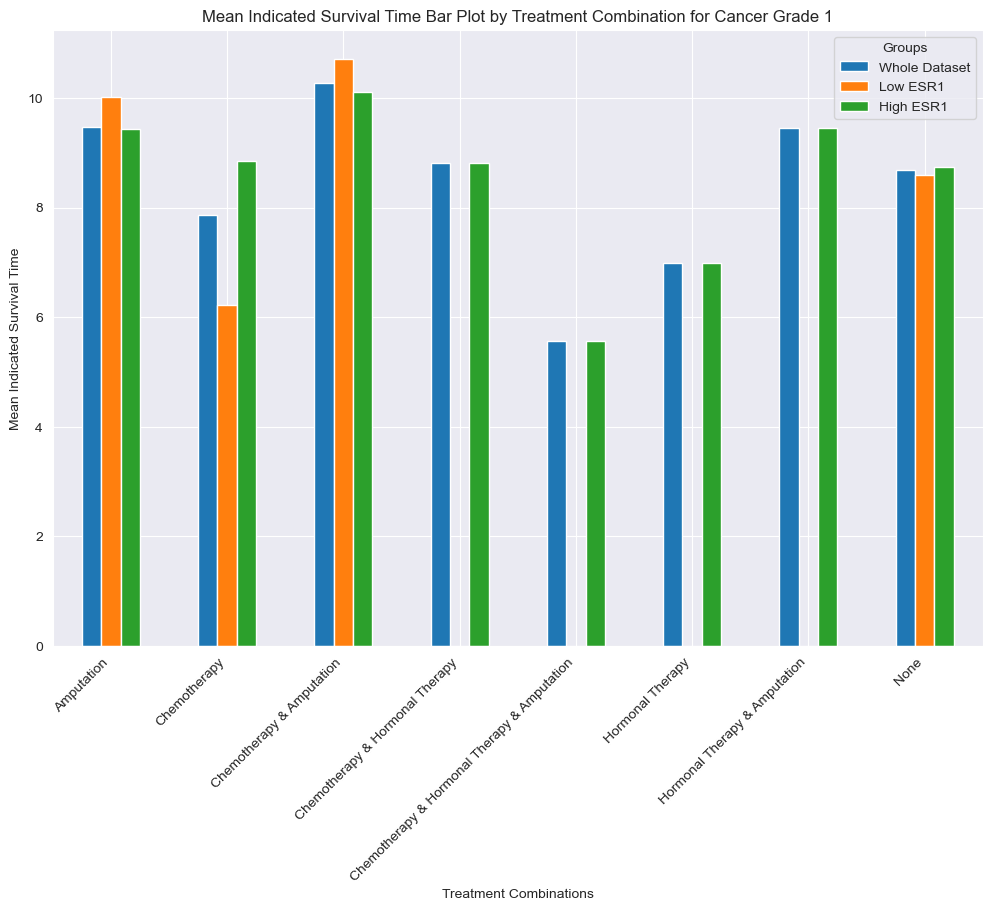

<Figure size 1200x800 with 0 Axes>

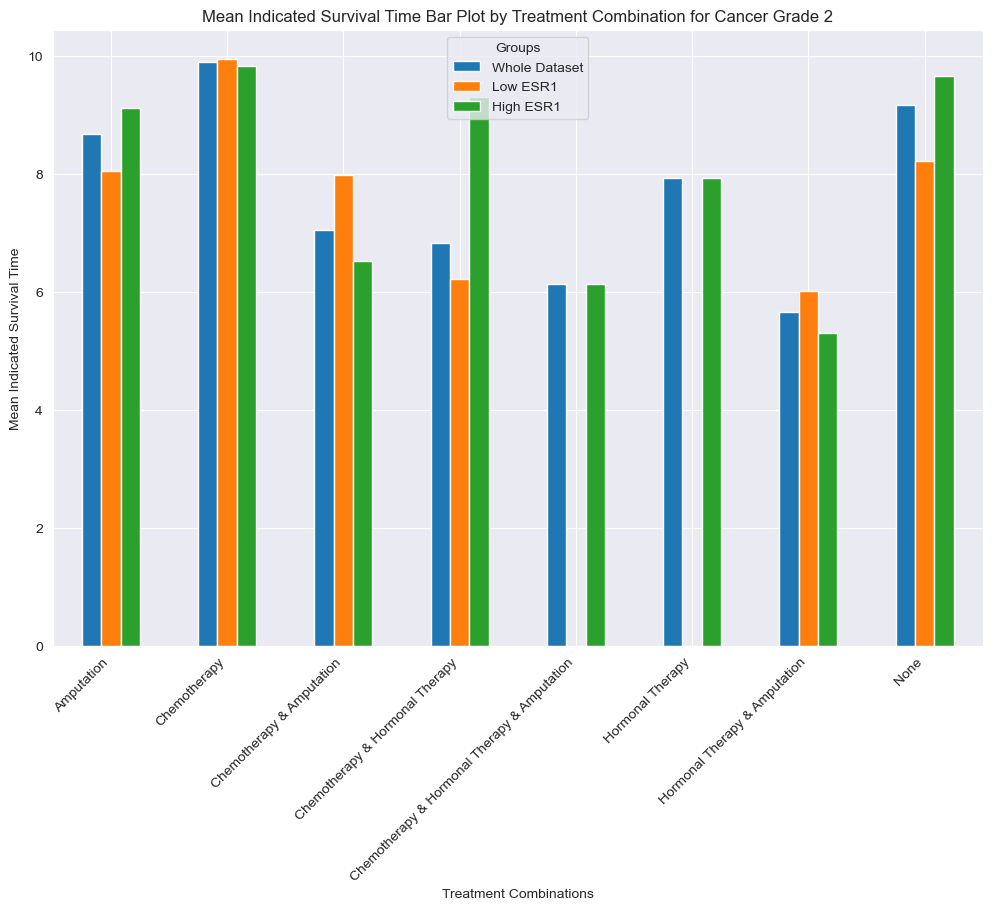

<Figure size 1200x800 with 0 Axes>

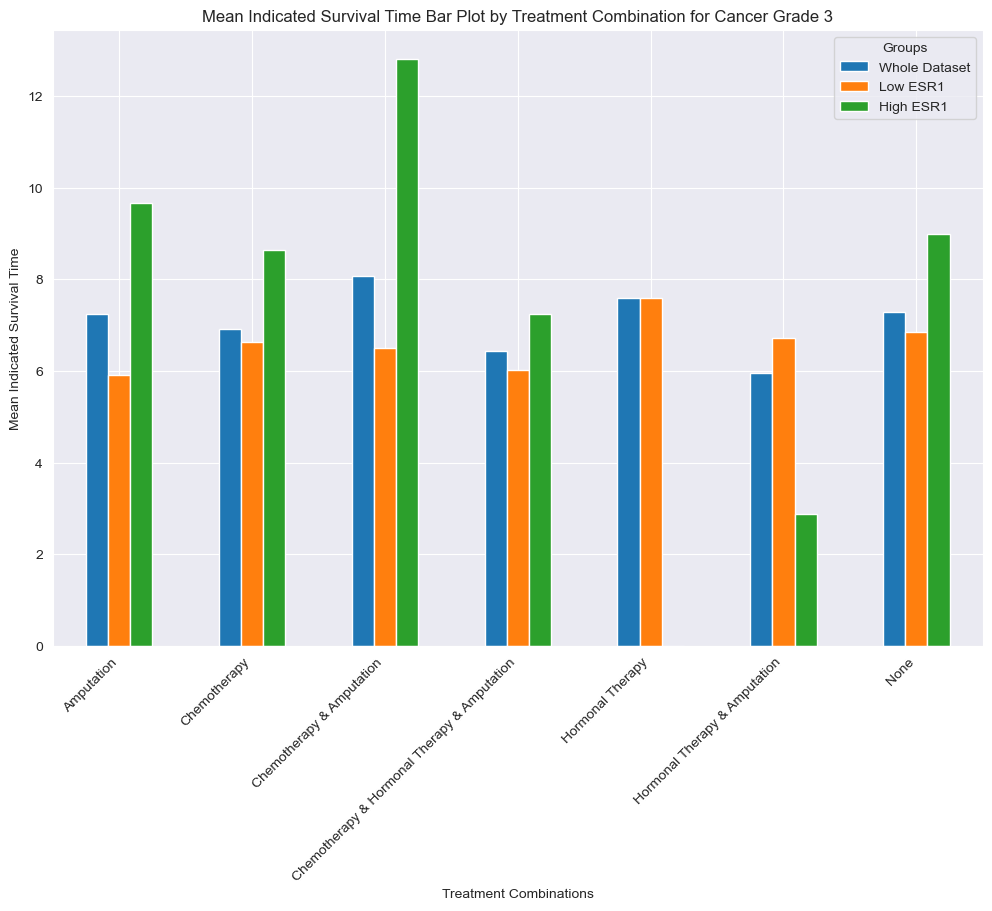

In [33]:
# Creating bar plots for each grade of cancer detailing mean indicated survival times for: whole dataset, low ESR1 group and high ESR1 group
grades = [1, 2, 3]

for grade in grades:
    plt.figure(figsize=(12, 8))
    
    # Parsing data
    bcd_group = bcd[bcd["Cancer Grade"] == grade]
    low_esr1_group = low_esr1[low_esr1["Cancer Grade"] == grade]
    high_esr1_group = high_esr1[high_esr1["Cancer Grade"] == grade]
    
    # Calculating means
    bcd_mean = bcd_group.groupby("Treatment Combinations")["Indicated Survival Time"].mean()
    low_esr1_mean = low_esr1_group.groupby("Treatment Combinations")["Indicated Survival Time"].mean()
    high_esr1_mean = high_esr1_group.groupby("Treatment Combinations")["Indicated Survival Time"].mean()
    
    combined = pd.DataFrame({"Whole Dataset": bcd_mean, "Low ESR1": low_esr1_mean, "High ESR1": high_esr1_mean})
    
    combined.plot(kind="bar", figsize=(12, 8))
    plt.xlabel("Treatment Combinations")
    plt.ylabel("Mean Indicated Survival Time")
    plt.title("Mean Indicated Survival Time Bar Plot by Treatment Combination for Cancer Grade " + str(grade))
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Groups")
    plt.show()